<h1>Train — InceptionNet v3</h1>

Trains and evaluates InceptionNet v3 using the tuned hyperparameters from `ARCH_HYPERPARAMS["inception_v3"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1742 | Val: 489 | Test: 276


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["inception_v3"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"InceptionNet v3: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

InceptionNet v3: micro batch = 4, accumulation steps = 4 (effective batch size ≈ 16, tuned value = 17)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with InceptionNet v3)
# ---------------------------------------------------------
model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True)

in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

# The auxiliary classifier (used only during training, see run_epoch in
# wwtw_utils.py) also needs its output layer resized to our number of classes.
in_f_aux = model.AuxLogits.fc.in_features
model.AuxLogits.fc = nn.Linear(in_f_aux, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[InceptionNet v3] Using gradient accumulation: 4 micro-batches per optimizer step (effective batch size ≈ micro_batch x 4).
[InceptionNet v3] Epoch   1/100 | LR: 1.43e-04 | train loss 1.5802 acc 0.514 | val loss 0.8109 acc 0.601 *
[InceptionNet v3] Epoch   2/100 | LR: 1.43e-04 | train loss 1.2383 acc 0.616 | val loss 0.8308 acc 0.497
[InceptionNet v3] Epoch   3/100 | LR: 1.43e-04 | train loss 1.1854 acc 0.652 | val loss 0.6706 acc 0.742 *
[InceptionNet v3] Epoch   4/100 | LR: 1.43e-04 | train loss 1.0084 acc 0.685 | val loss 0.7631 acc 0.744
[InceptionNet v3] Epoch   5/100 | LR: 1.43e-04 | train loss 0.9966 acc 0.722 | val loss 0.6887 acc 0.742
[InceptionNet v3] Epoch   6/100 | LR: 1.43e-04 | train loss 0.9099 acc 0.737 | val loss 0.7276 acc 0.730
[InceptionNet v3] Epoch   7/100 | LR: 1.43e-04 | train loss 0.9080 acc 0.739 | val loss 0.6516 acc 0.798 *
[InceptionNet v3] Epoch   8/100 | LR: 1.43e-04 | train loss 0.8172 acc 0.766 | val loss 0.7263 acc 0.793
[InceptionNet v3] Epoch   9/10

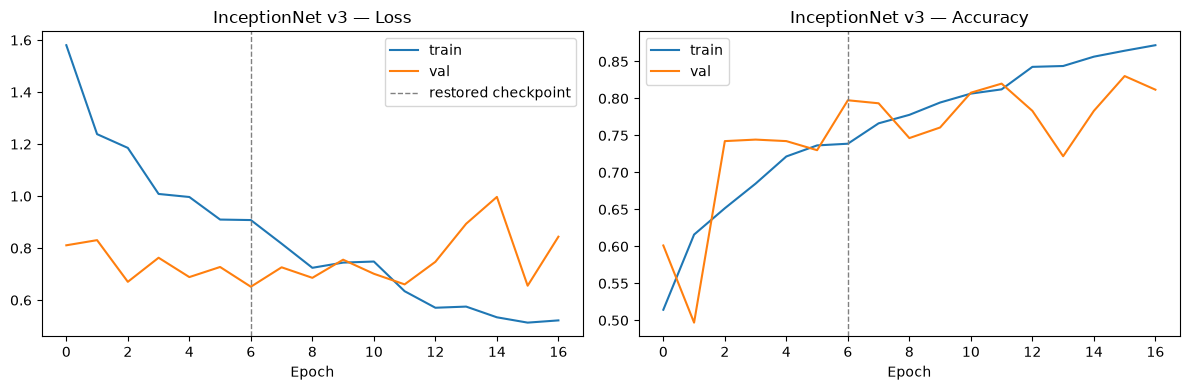

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "InceptionNet v3", is_inception=True,
    accum_steps=accum_steps,
)
plot_training_curves(history, "InceptionNet v3")

## Evaluate on the test set

[InceptionNet v3] Test accuracy: 0.797


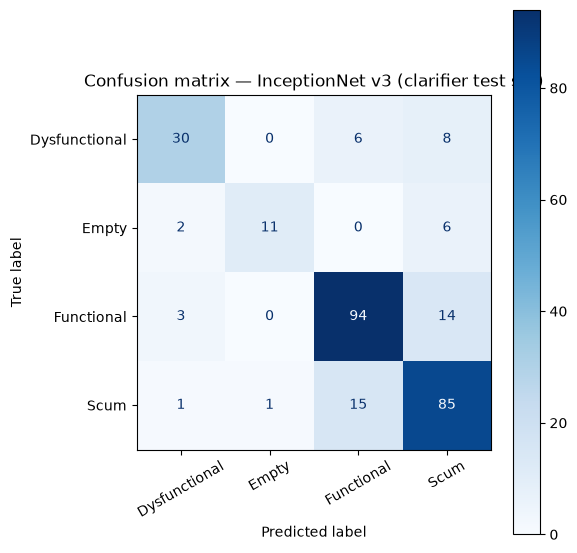

               precision    recall  f1-score   support

Dysfunctional      0.833     0.682     0.750        44
        Empty      0.917     0.579     0.710        19
   Functional      0.817     0.847     0.832       111
         Scum      0.752     0.833     0.791       102

     accuracy                          0.797       276
    macro avg      0.830     0.735     0.771       276
 weighted avg      0.803     0.797     0.795       276



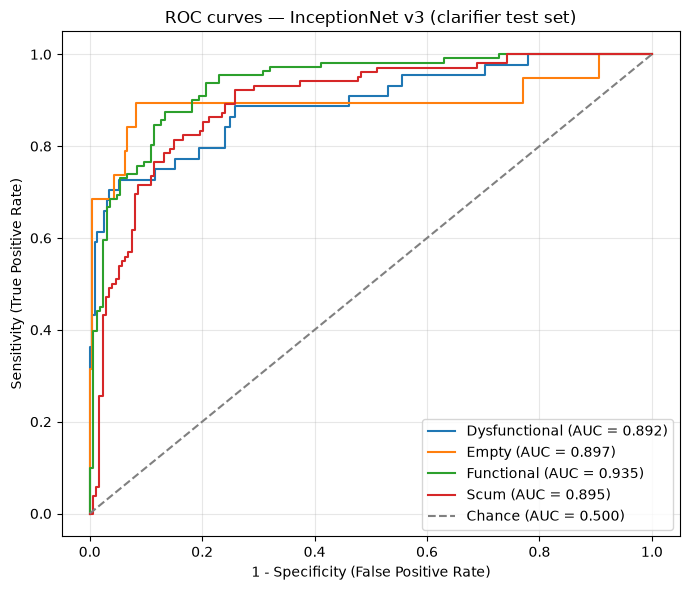

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.892
  Empty          : 0.897
  Functional     : 0.935
  Scum           : 0.895

Mean AUC: 0.905


(np.float64(0.7971014492753623),
 {'Dysfunctional': 0.8923393416927898,
  'Empty': 0.896989555601065,
  'Functional': 0.9350805350805351,
  'Scum': 0.8954811809781383})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "InceptionNet v3", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("InceptionNet v3", "inception_v3")

Saved results to ../results/results_inception_v3.pkl
Saved model weights to ../models/clarifier_inception_v3_cnn.pt
